In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk
import numpy as np
import pathlib
import seaborn as sns
from scipy.stats import skew, kurtosis

In [2]:
manifest_path = "/Users/furkan/projects/mebar-radiology/data/manifest.csv"
manifest_df = pd.read_csv(manifest_path)
manifest_df = manifest_df.set_index("sample_id")

## Intensity Distribution

Statistics on intensity.

In [3]:
def get_abs_path(relative_path):
    root_dir = pathlib.Path.cwd().parent
    return root_dir / relative_path

def _extract_statistics(values):

	percentiles = np.percentile(
		values,
		[1, 5, 25, 50, 75, 95, 99]
	)

	p01, p05, p25, p50, p75, p95, p99 = percentiles

	return {
            "count": len(values),
			"min": values.min(),
			"max": values.max(),
            "mean": values.mean(),
            "std": values.std(),
           	"p01": p01,
            "p05": p05,
            "p25": p25,
            "p50": p50,
            "p75": p75,
            "p95": p95,
            "p99": p99,
            "iqr": p75-p25,
            "skewness": skew(values),
            "kurtosis": kurtosis(values),
        }

def statistics(sample_id):
	row = manifest_df.loc[sample_id]
	mask_path = get_abs_path(row["mask_path"])
	img_path = get_abs_path(row["image_path"])

	image = sitk.ReadImage(img_path)
	mask = sitk.ReadImage(mask_path)

	image_array = sitk.GetArrayFromImage(image)
	mask_array = sitk.GetArrayFromImage(mask)

	if image_array.shape != mask_array.shape:
		raise ValueError(
			f"Shape mismatch: {row['sample_id']}"
		)

	# maps invalid voxels to 0, valids to 1
	finite = np.isfinite(image_array)

	foreground = finite & (image_array != 0) & (image_array != -256)
	tumor = finite & (mask_array != 0)

	foreground_results = _extract_statistics(image_array[foreground])

	tumor_results = _extract_statistics(image_array[tumor])

	return (
		foreground_results,
		tumor_results
	)


In [10]:
# mask - image shape and origin mismatch causes fail

rows = []
failed = []

for sample_id, row in manifest_df.iterrows():
    try:
        foreground_results, tumor_results = statistics(sample_id)

        rows.append({
            "sample_id": sample_id,
            "modality": row["modality"],
            "response_group": row["response_group"],
            "batch_id":row["batch_id"],
            **{f"foreground_{k}": v for k, v in foreground_results.items()},
            **{f"tumor_{k}": v for k, v in tumor_results.items()},
        })

    except Exception as e:
        print(f"sample with id {sample_id} failed: {e}")
        failed.append(sample_id)

results_df = pd.DataFrame(rows)

sample with id 2fa95f062483ba1b failed: 'sample_id'


In [11]:
pd.set_option('display.max_columns', None)
results_df.describe()

,foreground_count,foreground_mean,foreground_std,foreground_p01,foreground_p05,foreground_p25,foreground_p50,foreground_p75,foreground_p95,foreground_p99,foreground_iqr,foreground_skewness,foreground_kurtosis,tumor_count,tumor_mean,tumor_std,tumor_p01,tumor_p05,tumor_p25,tumor_p50,tumor_p75,tumor_p95,tumor_p99,tumor_iqr,tumor_skewness,tumor_kurtosis
count,3.750000e+02,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000
mean,3.478967e+06,566.002573,395.333535,24.592015,70.273352,242.233459,508.586037,816.206965,1288.148494,1665.748134,573.973506,0.630237,0.181025,19115.232000,624.704324,136.127388,359.335606,427.110410,528.696767,612.752463,707.975776,863.785569,988.280441,179.279009,0.571405,1.139291
std,4.177432e+06,361.747165,249.537137,56.844842,96.647534,202.852936,340.186356,481.517937,864.345452,1147.935004,323.136824,0.546448,1.581461,33789.705157,491.053266,121.094582,292.806187,336.766242,414.192163,485.785939,564.550969,684.568794,769.746795,176.829676,0.457384,1.690465
min,1.759790e+05,0.383890,0.340561,-1.000000,-1.000000,-1.000000,-0.001284,0.680002,1.135584,1.473008,0.475407,-0.580912,-1.578898,113.000000,0.655809,0.123612,0.354491,0.478975,0.555897,0.611011,0.701017,0.996293,1.264807,0.145120,-0.821629,-1.626945
25%,7.716515e+05,276.783473,189.240848,3.000000,6.500000,78.000000,245.000000,438.000000,569.000000,651.000000,337.500000,0.194354,-1.139257,1657.000000,225.148937,44.874883,121.500000,151.000000,192.500000,222.500000,254.250000,309.500000,353.000000,54.000000,0.290220,0.220699
50%,2.287071e+06,553.237676,397.947301,16.000000,53.000000,213.000000,465.000000,813.000000,1264.000000,1597.279121,559.000000,0.591302,-0.494965,5335.000000,584.812500,107.967894,326.000000,402.000000,499.094505,571.142857,652.984615,799.200000,921.000000,134.250000,0.538294,0.878374
75%,4.088560e+06,833.590968,575.182047,31.000000,99.000000,358.000000,743.500000,1171.580464,1874.500000,2668.000000,803.500000,0.994986,1.355022,21382.000000,932.361527,194.928410,543.040000,635.777198,788.000000,896.000000,1046.500000,1273.025000,1462.830000,251.875000,0.838947,1.527635
max,2.036338e+07,1854.572989,1209.090218,952.000000,1289.000000,1367.000000,1864.000000,2726.000000,4095.000000,4323.000000,2290.000000,2.559780,6.895771,373100.000000,2689.494361,728.061613,1865.000000,2070.800000,2409.000000,2696.000000,2976.000000,3527.500000,3901.060000,1391.500000,2.992540,18.038977


**ATTENTION!** sample 14 seems quite abnormal. It seems like imaging scaled very differently from others, might be related to batch, if different batches generated by different machines. Check if there are other samples like them, **scaled in very small values**:

In [ ]:
# detect small scaled samples
adc_results = results_df[
    results_df["modality"] == "ADC"
].copy()

adc_results["scale_group"] = np.where(
    adc_results["foreground_p99"] < 10,
    "small_scale",
    "large_scale"
)

adc_results["scale_group"].value_counts()

scale_group
large_scale    165
small_scale     22
Name: count, dtype: int64

In [ ]:
adc_info = adc_results.merge(
    manifest_df[
        [
            "batch_id",
            "image_dtype",
            "image_encoding",
            "response_group"
        ]
    ],
    left_on="sample_id",
    right_index=True,
    how="left",
    suffixes=("", "_manifest")
)

pd.crosstab(
    adc_info["batch_id"],
    adc_info["scale_group"],
    margins=True
)

scale_group,large_scale,small_scale,All
batch_id,,,
batch-1,88,11,99
batch-2,77,11,88
All,165,22,187


Not related to batch, appearently. But there are 22 total small scaled imagings. **Small scaled and large scaled imagings min-max intensities are x1000 different, seemingly (intuitive)**. Check if large scaled imagings are really large scaled.

/var/folders/4j/vmfcbk011r1d4ztywrf3d_rh0000gn/T/ipykernel_67740/595126451.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


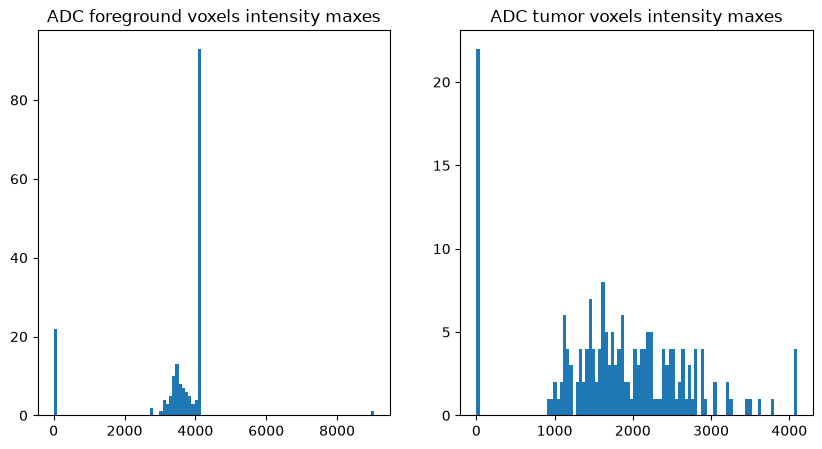

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].hist(adc_results["foreground_max"], bins=100)
axes[0].set_title("ADC foreground voxels intensity maxes")

axes[1].hist(adc_results["tumor_max"], bins=100)
axes[1].set_title("ADC tumor voxels intensity maxes")
fig.show()

Histogram strengthens the 1000x scale difference assumption between ADC imagings. 1000 is not certain, but ~1000 times scale difference is clear now. Now we should detect the number precisely, if approx. medians are ~1000 times scaled, we might assume so.

In [25]:
adc_info.groupby("scale_group")["tumor_p50"].median()

scale_group
large_scale    919.000000
small_scale      0.931219
Name: tumor_p50, dtype: float64

We have a very strong indicator of a scale difference. We should consider this when preprocessing data, possibly rescaling small scaled samples by 1000x.
<br>**Below is how data would seem like if small scaled samples rescaled 1000x:**

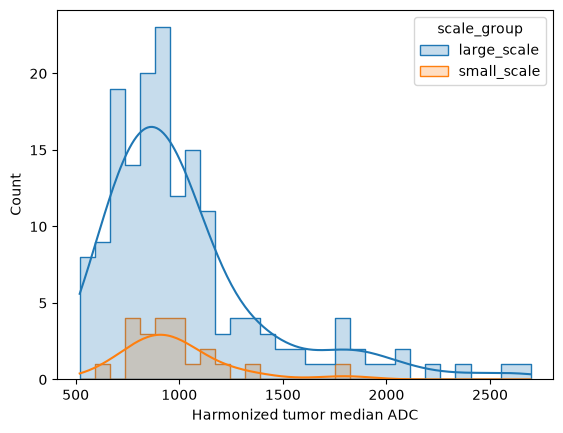

In [26]:
adc_info["corrected_tumor_p50"] = np.where(
    adc_info["scale_group"] == "small_scale",
    adc_info["tumor_p50"] * 1000,
    adc_info["tumor_p50"]
)

sns.histplot(
    data=adc_info,
    x="corrected_tumor_p50",
    hue="scale_group",
    bins=30,
    kde=True,
    element="step",
    common_norm=False
)

plt.xlabel("Harmonized tumor median ADC")
plt.show()

Our assumptions seem correct. Almost perfectly fits when small scaled ones scales by 1000x. Just to make sure, also check other percentiles:

In [27]:
adc_info.groupby("scale_group").agg(
    count=("corrected_tumor_p50", "count"),
    median=("corrected_tumor_p50", "median"),
    q25=("corrected_tumor_p50", lambda x: x.quantile(0.25)),
    q75=("corrected_tumor_p50", lambda x: x.quantile(0.75)),
    mean=("corrected_tumor_p50", "mean"),
)

,count,median,q25,q75,mean
scale_group,,,,,
large_scale,165,919.000000,769.000000,1117.500000,1027.712121
small_scale,22,931.219268,844.024247,1030.448046,978.114166


In [ ]:
group_medians = adc_info.groupby("scale_group")["tumor_p50"].median()

ratio = (
    group_medians["large_scale"]
    / group_medians["small_scale"]
)

print("Scale ratio:", ratio)

Ölçek oranı: 986.8782050834429


## Intensity vs Labels (T2)

In [30]:
t2_df = results_df[results_df["modality"] == "T2"]

Raw (not normalized yet) plot:

Text(0.5, 1.0, 'T2 p75 intensity vs labels')

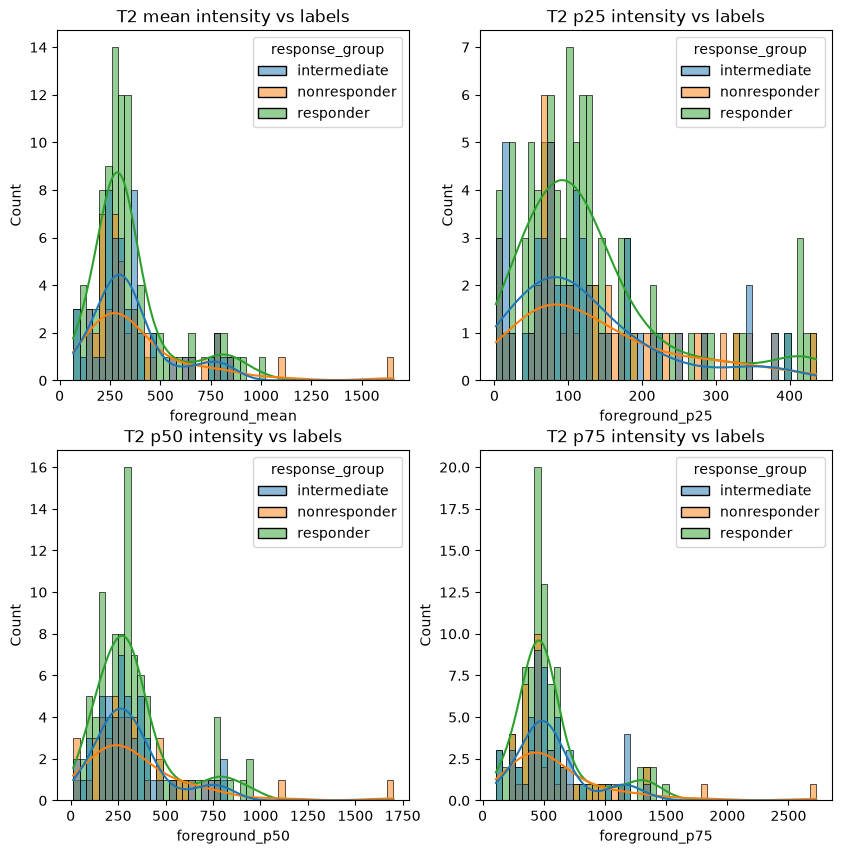

In [48]:
fig, axes = plt.subplots(2,2,figsize=(10,10))

sns.histplot(
	data=t2_df,
	x="foreground_mean",
	hue="response_group",
	kde=True,
	ax=axes[0][0],
	bins=50
)
axes[0][0].set_title("T2 mean intensity vs labels")

sns.histplot(
	data=t2_df,
	x="foreground_p25",
	hue="response_group",
	kde=True,
	ax=axes[0][1],
	bins=50
)
axes[0][1].set_title("T2 p25 intensity vs labels")

sns.histplot(
	data=t2_df,
	x="foreground_p50",
	hue="response_group",
	kde=True,
	ax=axes[1][0],
	bins=50
)
axes[1][0].set_title("T2 p50 intensity vs labels")

sns.histplot(
	data=t2_df,
	x="foreground_p75",
	hue="response_group",
	kde=True,
	ax=axes[1][1],
	bins=50
)
axes[1][1].set_title("T2 p75 intensity vs labels")

After normalization:

## Intensity vs Labels (ADC)

In [ ]:
# 3 different approach: visualize small scaled - large scaled separately, then rescaled, alltogether

**CONCLUSION:** Intensities are very very imbalanced, a normalization is necessary. T2 and ADC modalities are different in meaningful domains, and should be normalized differently:

**T2:** Apply z-score normalization to each sample, with mean=0, std=1.

**ADC:** ADC modality should not be normalized, as the values are meaningful as they are. But appearnentyl, when imaging done, a unit scale difference happened. This is not a normalization but small scaled images should be rescaled to scale of other imagings.